In [1]:
import sys
sys.path.append('/global/homes/c/cpopik/')
from Basics import *
setplot(dark=True)

In [2]:
ymappath = "/global/cfs/projectdirs/act/www/dr6_nilc/ymaps_20230220"  # location of y maps
ymapfiles = {'Base': {'NA': {'NA': "ilc_actplanck_ymap.fits"}}}  # Define undeprojected map
for deproj in os.listdir(f"{ymappath}/deprojections"):  # for every deproj method
    filenames = os.listdir(f"{ymappath}/deprojections/{deproj}")  # all deproj files
    TCIBs = np.unique([f"{(f.split('_')[-1])[:-5]:.04}" for f in filenames])  # all TCIBs
    ymapfiles[deproj] = {TCIB: {} for TCIB in TCIBs}  # make TCIB dicts
    for filename in filenames:  # for every TCIB/beta
        TCIB = f"{filename.split('_')[-1][:-5]}"  # TCIB of file
        beta = filename.split('_')[-2]  # beta of file
        ymapfiles[deproj][f'{TCIB:.04}'][beta] = f"{deproj}/ilc_actplanck_ymap_deproj_{deproj}_{beta}_{TCIB}.fits"  # set filename

ymapfiles

In [7]:
ymapfiles

{'Base': {'NA': {'NA': 'ilc_actplanck_ymap.fits'}},
 'cib_cibdBeta': {'10.7': {'1.6': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.6_10.7.fits',
   '1.8': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.8_10.7.fits',
   '1.2': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.2_10.7.fits',
   '1.0': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.0_10.7.fits',
   '1.7': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.7_10.7.fits',
   '2.0': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_2.0_10.7.fits',
   '1.4': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.4_10.7.fits'},
  '24.0': {'1.4': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.4_24.0.fits',
   '1.45': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.45_24.00.fits',
   '1.2': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.2_24.0.fits',
   '1.15': 'cib_cibdBeta/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.15_24.00.fits',
   '1.35': 'cib_cibdBeta/ilc_actplanck_y

In [11]:
ViewDataOrganization("/global/cfs/projectdirs/act/www/dr6_nilc/ymaps_20230220/" )


These are ILC Compton-y maps made from Planck (LFI+HFI) and ACT DR6v3 maps.

All maps are in Compton y units.
In the deprojections folder are four subfolders: cib  cib_cibdBeta  cib_cibdT  cib_cibdBeta_cibdT 
These contain Compton-y maps with the CIB deprojected, the CIB and the spectral index moment deprojected, the CIB and the temperature moment deprojected and the CIB with both the spectral index and temperature moment deprojected.
Maps with CIB deprojections have two numbers in the names: e.g. _1.70_10.47_ the first number is the cib beta and the second is the cib temperature.


In the mask directory are four masks:
wide_mask_GAL070_apod_1.50_deg_wExtended.fits is the area footprint mask. The edges of the mask are apodized. 
inpainted_regions_mask.fits denotes the locations inpainted sources.
mask_subtracted_sources.fits contains the locations of subtracted sources.
cluster_mask.fits contains a mask that masks either confiirmed clusters or those detected with SNR>6.  This is NOT u

In [ ]:
ViewDataOrganization('/global/cfs/projectdirs/sdss/data/sdss/dr12/boss/spectro/redux/galaxy/v1_1', info=True)

No README file
/global/cfs/projectdirs/sdss/data/sdss/dr12/boss/spectro/redux/galaxy/v1_1/                                     2 Dirs
     granada_fsps_krou_wideform_dust-DR12-boss.fits.gz                                                              
     portsmouth_emlinekin_full-v5_7_0.fits.gz                                                                       
     portsmouth_emlinekin-v5_7_0.fits.gz                                                                            
     portsmouth_stellarmass_passive_salp-v5_7_0.fits.gz                                                             
     granada_fsps_salp_wideform_dust-DR12-boss.fits.gz                                                              
     granada_fsps_salp_wideform_nodust-v5_7_2.fits.gz                                                               
     granada_fsps_salp_wideform_nodust-DR12-boss.fits.gz                                                            
     portsmouth_stellarmass_starforming_krou-v5

# Zhou 2023


In [3]:
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')
from Models import Data, SMFs, HODs
importlib.reload(HODs)

<module 'Models.HODs' from '/global/homes/c/cpopik/CAPPIBARAS/Models/HODs.py'>

In [4]:
zdistfile = "/global/homes/c/cpopik/CAPPIBARAS/Data/Zhou2023B/main_lrg_pz_dndz_iron_v0.4_dz_0.02.txt"
cols = pd.read_csv(zdistfile, sep=" ", nrows=1).columns[1:]
zdf = pd.read_csv(zdistfile, sep=" ", skiprows=1, names=cols)
zs = (zdf.zmin+zdf.zmax)/2

In [5]:
zave1 = np.trapz(zs.values*zdf.bin_1_combined.values, zs.values)/np.trapz(zdf.bin_1_combined.values, zs.values)
zave2 = np.trapz(zs.values*zdf.bin_2_combined.values, zs.values)/np.trapz(zdf.bin_2_combined.values, zs.values)
zave3 = np.trapz(zs.values*zdf.bin_3_combined.values, zs.values)/np.trapz(zdf.bin_3_combined.values, zs.values)
zave4 = np.trapz(zs.values*zdf.bin_4_combined.values, zs.values)/np.trapz(zdf.bin_4_combined.values, zs.values)

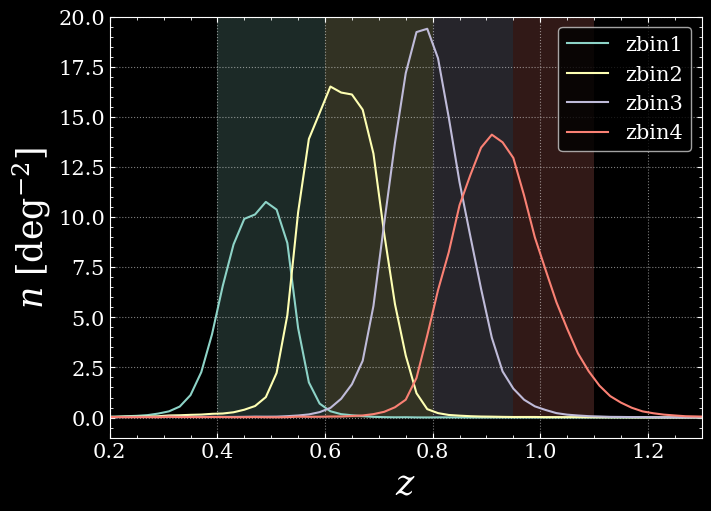

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5), layout='constrained')

ax.fill_betweenx(np.linspace(0, 25), 0.4, 0.6, alpha=0.2)
ax.fill_betweenx(np.linspace(0, 25), 0.6, 0.8, alpha=0.2)
ax.fill_betweenx(np.linspace(0, 25), 0.8, 0.95, alpha=0.2)
ax.fill_betweenx(np.linspace(0, 25), 0.95, 1.1, alpha=0.2)

ax.plot(zs.values, zdf.bin_1_combined.values, label='zbin1')
ax.plot(zs.values, zdf.bin_2_combined.values, label='zbin2')
ax.plot(zs.values, zdf.bin_3_combined.values, label='zbin3')
ax.plot(zs.values, zdf.bin_4_combined.values, label='zbin4')

ax.set(ylim=(-1, 20), xlim=(0.2, 1.3), xlabel=r'$z$', ylabel=r'$n$ [deg$^{-2}$]'); ax.legend()
plt.show()

# Liu 2025

In [7]:
Liupath = '/global/homes/c/cpopik/CAPPIBARAS/Data/Liu2025'

# Spectroscopic distributions of four sub-sample photometric redshift bins, derived from 2.3 million DESI spectroscopic redshifts. The unit on the y axis are the number of galaxies per square degree within the redshift bin, with widthdz = 0.01.
Liu1 = np.genfromtxt(f"{Liupath}/fig2_main_lrg_pz_dndz_iron_v0.4_dz_0.01.txt")

# ACT DR6 fiducial y-parameter stacked profiles alongside stacked profiles using deprojected CIB y-parameter maps with varying values of the β parameter.
Liu3 = pd.read_csv(f"{Liupath}/fig3.csv")

# ACT DR6 fiducial y-parameter stacked profiles alongside the profiles stacked on dβ moment-deprojected, CIBdeprojected y-parameter maps, with varying values of β
Liu4 = pd.read_csv(f"{Liupath}/fig4.csv")

# Correlation Matrix between the different CAP filters for the stacked profile from the ACT DR6 fiducial y-parameter map
Liu6 = {f'pz{zbin}': np.load(f"{Liupath}/fig6_pz{zbin}.npy") for zbin in [1, 2, 3, 4]}

# Non-Cumulative variant of Figure 3 showing the stacked profiles for the fiducial and CIB-deprojected y- parameter maps
Liu7 = pd.read_csv(f"{Liupath}/fig7.csv")

# Non-Cumulative variant of Figure 4 showing the stacked profiles for the fiducial and dβ moment-deprojected CIB-deprojected y-parameter maps.
Liu8 = pd.read_csv(f"{Liupath}/fig8.csv")

# Correlation Matrix for stacking on the fiducial ACT DR6 y-parameter map, without CIB deprojection.
Liu9 = {f'pz{zbin}': np.load(f"{Liupath}/fig9_pz{zbin}.npy") for zbin in [1, 2, 3, 4]}

# ACT DR6 stacked profiles alongside the deprojected CIB profiles with varying values of β, for TCIB = 24.0K.
Liu10 = pd.read_csv(f"{Liupath}/fig10.csv")

# CT DR6 stacked profiles alongside the deprojected CIB and dβ profiles, with varying values of β, for TCIB = 24.0K.
Liu11 = pd.read_csv(f"{Liupath}/fig11.csv")

# Plot of the ACT DR5 stacked profiles using the standard CAP filter as described by the window function in Equation 5. Note that the tSZ stacked profiles shown in the main body are all computed with the same filter.
Liu12 = pd.read_csv(f"{Liupath}/fig12.csv")

# Plot of the ACT DR5 stacked profiles using the ring-ring filter. The filter masks out the central area of the stack following Equation A1, with θ0 = 1 arcmin.
Liu13 = pd.read_csv(f"{Liupath}/fig13.csv")

In [58]:
zdf=pd.DataFrame(np.genfromtxt(f"{Liupath}/fig2_main_lrg_pz_dndz_iron_v0.4_dz_0.01.txt"), 
             columns=pd.read_csv(f"{datapath}/Zhou2023B/main_lrg_pz_dndz_iron_v0.4_dz_0.02.txt", sep=" ", nrows=1).columns[1:])

In [61]:
zdf

,zmin,zmax,all_combined,bin_1_combined,bin_2_combined,bin_3_combined,bin_4_combined,all_north,bin_1_north,bin_2_north,bin_3_north,bin_4_north,all_south,bin_1_south,bin_2_south,bin_3_south,bin_4_south
0,0.00,0.01,0.008,0.001,0.001,0.001,0.001,0.009,0.000,0.002,0.002,0.001,0.007,0.001,0.001,0.001,0.001
1,0.01,0.02,0.008,0.001,0.001,0.001,0.001,0.005,0.000,0.002,0.000,0.000,0.010,0.001,0.000,0.002,0.002
2,0.02,0.03,0.023,0.002,0.001,0.002,0.004,0.018,0.000,0.000,0.002,0.007,0.025,0.003,0.002,0.002,0.002
3,0.03,0.04,0.042,0.005,0.005,0.004,0.004,0.039,0.006,0.006,0.006,0.005,0.043,0.004,0.004,0.003,0.004
4,0.04,0.05,0.054,0.005,0.006,0.003,0.002,0.036,0.003,0.005,0.002,0.002,0.062,0.006,0.006,0.003,0.002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,1.44,1.45,0.019,0.000,0.001,0.002,0.001,0.017,0.000,0.002,0.002,0.000,0.019,0.001,0.000,0.002,0.002
145,1.45,1.46,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
146,1.46,1.47,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
147,1.47,1.48,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
pd.read_csv(f"{datapath}/Zhou2023B/main_lrg_pz_dndz_iron_v0.4_dz_0.02.txt").columns

AttributeError: module 'pandas' has no attribute 'read_txt'

In [56]:
pd.read_csv(f"{datapath}/Zhou2023B/main_lrg_pz_dndz_iron_v0.4_dz_0.02.txt", sep=" ", nrows=1).columns[1:]

Index(['zmin', 'zmax', 'all_combined', 'bin_1_combined', 'bin_2_combined',
       'bin_3_combined', 'bin_4_combined', 'all_north', 'bin_1_north',
       'bin_2_north', 'bin_3_north', 'bin_4_north', 'all_south', 'bin_1_south',
       'bin_2_south', 'bin_3_south', 'bin_4_south'],
      dtype='object')

In [34]:
datapath = "/global/homes/c/cpopik/CAPPIBARAS/Data"

path = f"{datapath}/Zhou2023B/"
sample='main'
zdistfile = f"{path}/{sample}_lrg_pz_dndz_iron_v0.4_dz_0.02.txt"  # open data file
cols = pd.read_csv(zdistfile, sep=" ", nrows=1).columns[1:]  # get columns from first row
zdfdata = pd.read_csv(zdistfile, sep=" ", skiprows=1, names=cols)  # format into dataframe
zdfdata

,zmin,zmax,all_combined,bin_1_combined,bin_2_combined,bin_3_combined,bin_4_combined,all_north,bin_1_north,bin_2_north,bin_3_north,bin_4_north,all_south,bin_1_south,bin_2_south,bin_3_south,bin_4_south
0,0.00,0.02,0.016,0.002,0.002,0.002,0.002,0.014,0.000,0.003,0.002,0.001,0.017,0.002,0.001,0.003,0.003
1,0.02,0.04,0.065,0.007,0.006,0.006,0.008,0.057,0.006,0.006,0.008,0.012,0.068,0.007,0.005,0.006,0.006
2,0.04,0.06,0.141,0.012,0.013,0.007,0.010,0.102,0.007,0.013,0.008,0.012,0.159,0.014,0.014,0.007,0.009
3,0.06,0.08,0.220,0.021,0.026,0.014,0.009,0.199,0.016,0.040,0.014,0.011,0.229,0.023,0.020,0.013,0.008
4,0.08,0.10,0.277,0.026,0.030,0.019,0.018,0.245,0.014,0.040,0.016,0.017,0.291,0.032,0.026,0.020,0.019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,1.38,1.40,0.077,0.001,0.002,0.003,0.009,0.063,0.000,0.002,0.003,0.009,0.083,0.001,0.002,0.004,0.009
70,1.40,1.42,0.064,0.001,0.001,0.003,0.006,0.066,0.002,0.000,0.006,0.006,0.063,0.001,0.002,0.001,0.006
71,1.42,1.44,0.042,0.001,0.001,0.002,0.005,0.034,0.000,0.000,0.000,0.003,0.045,0.001,0.001,0.002,0.006
72,1.44,1.46,0.019,0.000,0.001,0.002,0.001,0.017,0.000,0.002,0.002,0.000,0.019,0.001,0.000,0.002,0.002


[]

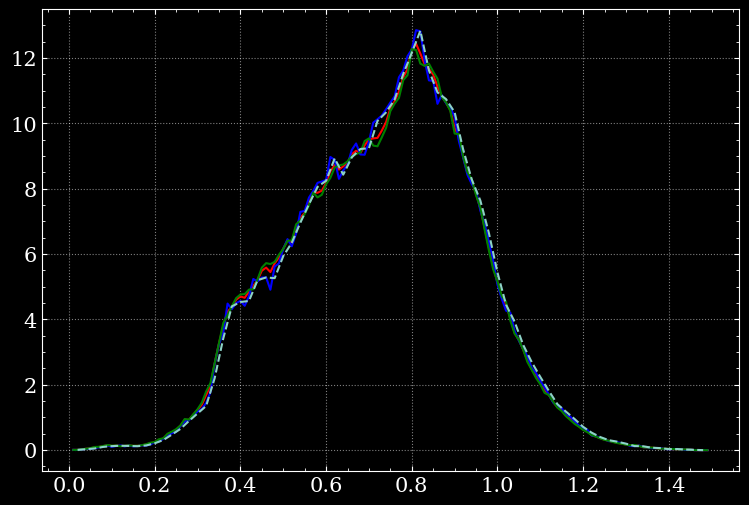

In [48]:
plt.plot(Liu1[:,1], Liu1[:,2], c='r')
plt.plot(Liu1[:,1], Liu1[:,7], c='b')
plt.plot(Liu1[:,1], Liu1[:,12], c='green')
plt.plot(zdfdata.zmax, zdfdata.all_north/2, ls='--')
plt.plot()

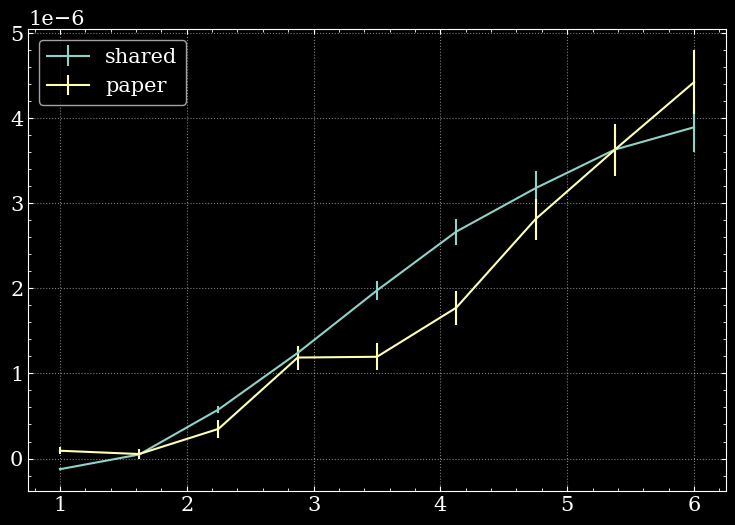

In [380]:
Rs_shared, ttsz_shared, ttsz_err_shared = np.genfromtxt("/global/homes/c/cpopik/Data/Liu2025_shared/DESI_pz1_act_dr6_fiducial/diskring_tsz_uniformweight_measured.txt").T
covmat_shared = np.genfromtxt("/global/homes/c/cpopik/Data/Liu2025_shared/DESI_pz1_act_dr6_fiducial/cov_diskring_tsz_uniformweight_bootstrap.txt")

ttsz_shared, ttsz_err_shared = ttsz_shared*u.sr.to(u.arcmin**2), ttsz_err_shared*u.sr.to(u.arcmin**2)
covmat_shared = covmat_shared*u.sr.to(u.arcmin**2)**2

Rs_paper = Liu4.RApArcmin.values[:-1]
ttsz_paper = Liu4['pz1_act_dr6_fiducial'].values[:-1]
ttsz_err_paper = Liu4['pz1_act_dr6_fiducial_err'].values[:-1]
corrmat_paper = Liu6['pz1']

plt.errorbar(Rs_shared, ttsz_shared, ttsz_err_shared, label='shared')
plt.errorbar(Rs_paper, ttsz_paper, ttsz_err_paper, label='paper')
plt.legend()

In [389]:
corr_diag = np.sqrt(np.diag(corrmat_paper))
corr_norm_paper = corrmat_paper / np.outer(corr_diag, corr_diag)

In [390]:
# If you construct a normalized correlation matrix from the SHARED covariance matrix, it's equivalent to the PAPER correlation matrix
D = np.sqrt(np.diag(covmat_shared))
corrmat_from_shared = covmat_shared / np.outer(D, D)

corr_norm_paper/corrmat_from_shared

array([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [400]:
# If you make a covmat from the PAPER norm corr matrix and PAPER errors, same as PAPER errors, different from SHARED errors, different from SHARED covmat
covmat_from_paper = corr_norm_paper * np.outer(ttsz_err_paper, ttsz_err_paper)
np.diag(covmat_from_paper)**0.5/ttsz_err_paper, np.diag(covmat_from_paper)**0.5/ttsz_err_shared, covmat_from_paper/covmat_shared

(array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([4.0314524 , 2.42778591, 2.34088792, 1.93043965, 1.45127226,
        1.31720389, 1.21813015, 1.23779038, 1.29420427]),
 array([[16.08736532,  9.66200904,  9.14658791,  7.64406453,  5.82211626,
          5.33757746,  4.91678029,  4.97197305,  5.16311148],
        [ 9.66200904,  5.80296505,  5.49340512,  4.59099543,  3.49674038,
          3.20572826,  2.95299912,  2.98614768,  3.10094467],
        [ 9.14658791,  5.49340512,  5.20035871,  4.34608818,  3.31020631,
          3.03471827,  2.795471  ,  2.82685124,  2.93552438],
        [ 7.64406453,  4.59099543,  4.34608818,  3.63214992,  2.76643388,
          2.53620066,  2.33625489,  2.36248025,  2.45330149],
        [ 5.82211626,  3.49674038,  3.31020631,  2.76643388,  2.10705961,
          1.93170205,  1.77941297,  1.79938757,  1.86856174],
        [ 5.33757746,  3.20572826,  3.03471827,  2.53620066,  1.93170205,
          1.77093841,  1.63132341,  1.64963565,  1.71305288],
        [ 4.

In [ ]:
# If you make a covmat from the PAPER norm corr matrix and SHARED errors, differnt as PAPER errors, same as SHARED errors, same as SHARED covmat
covmat_from_paper = corr_norm_paper * np.outer(ttsz_err_shared, ttsz_err_shared)
np.diag(covmat_from_paper)**0.5/ttsz_err_paper, np.diag(covmat_from_paper)**0.5/ttsz_err_shared, covmat_from_paper/covmat_shared

(array([0.24804956, 0.41189793, 0.42718833, 0.51801671, 0.68905058,
        0.75918391, 0.82093034, 0.80789124, 0.77267555]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([[0.98983282, 0.98717811, 0.96920792, 0.98221504, 0.99510851,
         1.00514716, 1.00121091, 0.99636881, 0.9895714 ],
        [0.98717811, 0.98453051, 0.96660852, 0.97958076, 0.99243965,
         1.00245137, 0.99852568, 0.99369657, 0.98691739],
        [0.96920792, 0.96660852, 0.94901278, 0.96174887, 0.97437369,
         0.98420316, 0.98034892, 0.97560772, 0.96895195],
        [0.98221504, 0.97958076, 0.96174887, 0.97465588, 0.98745013,
         0.99741152, 0.99350556, 0.98870073, 0.98195563],
        [0.99510851, 0.99243965, 0.97437369, 0.98745013, 1.00041233,
         1.01050447, 1.00654724, 1.00167934, 0.9948457 ],
        [1.00514716, 1.00245137, 0.98420316, 0.99741152, 1.01050447,
         1.02069843, 1.01670128, 1.01178427, 1.0048817 ],
        [1.00121091, 0.99852568, 0.98034892, 0.99350556, 1.0065472

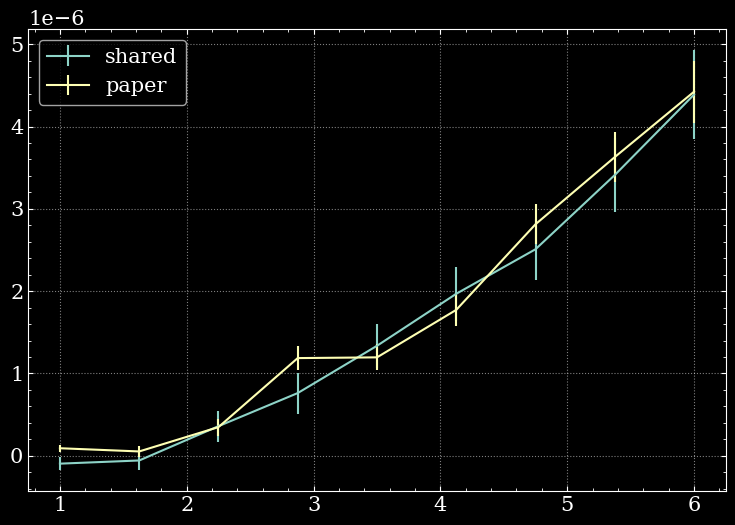

In [417]:
Rs_shared, ttsz_shared, ttsz_err_shared = np.genfromtxt("/global/homes/c/cpopik/Data/Liu2025_shared/DESI_pz1_act_dr6_dBeta_1.2_10.7/diskring_tsz_uniformweight_measured.txt").T
covmat_shared = np.genfromtxt("/global/homes/c/cpopik/Data/Liu2025_shared/DESI_pz1_act_dr6_dBeta_1.2_10.7/cov_diskring_tsz_uniformweight_bootstrap.txt")

ttsz_shared, ttsz_err_shared = ttsz_shared*u.sr.to(u.arcmin**2), ttsz_err_shared*u.sr.to(u.arcmin**2)
covmat_shared = covmat_shared*u.sr.to(u.arcmin**2)**2

Rs_paper = Liu4.RApArcmin.values[:-1]
ttsz_paper = Liu4['pz1_act_dr6_Beta_1.2'].values[:-1]
ttsz_err_paper = Liu4['pz1_act_dr6_Beta_1.2_err'].values[:-1]
corrmat_paper = Liu6['pz1']

plt.errorbar(Rs_shared, ttsz_shared, ttsz_err_shared, label='shared')
plt.errorbar(Rs_paper, ttsz_paper, ttsz_err_paper, label='paper')
plt.legend()

In [420]:
corr_diag = np.sqrt(np.diag(corrmat_paper))
corr_norm_paper = corrmat_paper / np.outer(corr_diag, corr_diag)

In [ ]:
# If you construct a PAPER norm correlation matrix from the SHARED covariance matrix, it's different to the PAPER correlation matrix
D = np.sqrt(np.diag(covmat_shared))
corrmat_from_shared = covmat_shared / np.outer(D, D)

corr_norm_paper/corrmat_from_shared

array([[  1.        ,   3.69193884,  -0.05326874,   0.17372578,
          3.9546516 ,  -0.21716238,   0.55633342,   0.26545374,
          2.03032196],
       [  3.69193884,   1.        ,   1.38624027,  -0.42381787,
         -2.92311466,   3.07543165,  -7.08894417,   3.77507974,
          1.08012179],
       [ -0.05326874,   1.38624027,   1.        ,  -3.41643774,
         -1.07354227,   9.43294359,   5.1961334 ,   3.61611917,
          2.31723735],
       [  0.17372578,  -0.42381787,  -3.41643774,   1.        ,
          4.90085546,  -1.79973646,   6.80862547,   1.65740986,
          1.93043136],
       [  3.9546516 ,  -2.92311466,  -1.07354227,   4.90085546,
          1.        ,   2.11205844, -12.63991283,  10.08360073,
          1.70614348],
       [ -0.21716238,   3.07543165,   9.43294359,  -1.79973646,
          2.11205844,   1.        ,   1.63565997,   6.43327278,
          4.41701007],
       [  0.55633342,  -7.08894417,   5.1961334 ,   6.80862547,
        -12.63991283,   1.6356

In [425]:
# If you make a covmat from the PAPER norm corr matrix and PAPER errors, same as PAPER errors, different from SHARED errors, different from SHARED covmat
covmat_from_paper = corr_norm_paper * np.outer(ttsz_err_paper, ttsz_err_paper)
np.diag(covmat_from_paper)**0.5/ttsz_err_paper, np.diag(covmat_from_paper)**0.5/ttsz_err_shared, covmat_from_paper/covmat_shared

(array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0.55548453, 0.54118277, 0.55284927, 0.56881559, 0.58556957,
        0.61032694, 0.65255778, 0.68311405, 0.69687198]),
 array([[ 0.31173358,  1.11006518, -0.01641505,  0.05537122,  1.28508274,
         -0.07421727,  0.20529295,  0.10229356,  0.78786156],
        [ 1.11006518,  0.29000426,  0.41202038, -0.13028952, -0.91617641,
          1.01376396, -2.52307888,  1.4031237 ,  0.40426684],
        [-0.01641505,  0.41202038,  0.30461831, -1.07641454, -0.3448484 ,
          3.18679274,  1.89541966,  1.37748976,  0.88887711],
        [ 0.05537122, -0.13028952, -1.07641454,  0.32587879,  1.62828719,
         -0.62887675,  2.56882534,  0.65301869,  0.76590625],
        [ 1.28508274, -0.91617641, -0.3448484 ,  1.62828719,  0.33873661,
          0.7524291 , -4.8620815 ,  4.05055334,  0.69014417],
        [-0.07421727,  1.01376396,  3.18679274, -0.62887675,  0.7524291 ,
          0.37467711,  0.66171152,  2.71786696,  1.87910122],
        [ 0.

In [432]:
np.diag(covmat_from_paper)**0.5, ttsz_err_paper

(array([7.82694110e-08, 1.17332283e-07, 1.87246661e-07, 2.48285756e-07,
        2.68895908e-07, 3.30686686e-07, 3.68974830e-07, 4.47106085e-07,
        5.39907442e-07]),
 array([4.34774466e-08, 6.34982105e-08, 1.03519181e-07, 1.41228808e-07,
        1.57457262e-07, 2.01826993e-07, 2.40777396e-07, 3.05424449e-07,
        3.76246369e-07]))

In [426]:
# If you make a covmat from the PAPER norm corr matrix and SHARED errors, differnt as PAPER errors, same as SHARED errors, different as SHARED covmat
covmat_from_paper = corr_norm_paper * np.outer(ttsz_err_shared, ttsz_err_shared)
np.diag(covmat_from_paper)**0.5/ttsz_err_paper, np.diag(covmat_from_paper)**0.5/ttsz_err_shared, covmat_from_paper/covmat_shared

(array([1.80023017, 1.84780456, 1.80881127, 1.75803902, 1.70773901,
        1.6384661 , 1.53243135, 1.46388439, 1.43498379]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([[  1.01027513,   3.69260241,  -0.05345194,   0.17524299,
           3.95075979,  -0.21891245,   0.56634764,   0.26957717,
           2.03528364],
        [  3.69260241,   0.99018522,   1.37710795,  -0.42324715,
          -2.89105689,   3.06923641,  -7.14443502,   3.79541069,
           1.07194165],
        [ -0.05345194,   1.37710795,   0.99664964,  -3.42295604,
          -1.06522898,   9.44462099,   5.25387412,   3.64744219,
           2.30718265],
        [  0.17524299,  -0.42324715,  -3.42295604,   1.00719395,
           4.88856074,  -1.81147152,   6.92060583,   1.68058661,
           1.93219573],
        [  3.95075979,  -2.89105689,  -1.06522898,   4.88856074,
           0.98788214,   2.10535113, -12.7240322 ,  10.12610985,
           1.69125197],
        [ -0.21891245,   3.06923641,   9.44462099,  -1.811

# Ried-Guachalla 2025

In [2]:
datapath = "/global/homes/c/cpopik/CAPPIBARAS/Data/"
Riedpath = f"{datapath}/RiedGuachalla2025"

# Redshift distribution of the DESI LRG Y1 galaxies overlapping the ACT map (∼ 39% of the total LRG sample).
zdist = dict(np.load(f"{Riedpath}/fig2_hist_z.npz"))

# The binned stellar mass distribution of the DESI LRG Y1 galaxies overlapping the ACT DR6 map
mdist = dict(np.load(f"{Riedpath}/fig3_mass_dist.npz"))

# The measured stacked kSZ in μK arcmin2 for varying CAP filters with radius R from Eq. 8 in brown.
stacked_ksz = dict(np.load(f"{Riedpath}/fig8_fiducial.npz"))

# Mean stacked kSZ profiles for the different redshift bins.
stacked_ksz_zbins = dict(np.load(f"{Riedpath}/fig11_ksz_z.npz"))

# Similar to Fig. 11, the kSZ stacked profiles for the different stellar mass bins, denoted by mass.
stacked_ksz_mbins = dict(np.load(f"{Riedpath}/fig12_ksz_mass.npz"))

# Comparison between the kSZ stacked CAP profiles obtained when using the different galaxy samples from DESI Y1: BGS (in purple) and ELG (in blue), both compared to the LRG main result.
stacked_ksz_othersamples = dict(np.load(f"{Riedpath}/fig14_other_samples.npz"))

# Comparison between the kSZ stacked CAP profiles obtained when using the photometric DESI LRG sample (from the DESI Legacy Imaging Surveys DR9 in red, subsample from what is used in [42]) and its spectroscopic counterpart (from DESI Y1 in brown).
stacked_ksz_ls_dr9 = dict(np.load(f"{Riedpath}/fig15_ls_dr9.npz"))

# The redshift distribution of the DESI LRG Y1 is shown for both the North Galactic Cap (NGC) and South Galactic Cap (SGC), along with the BOSS data.
zdist_boss = dict(np.load(f"{Riedpath}/fig20_hist_z.npz"))

# both the DESI Y1 and CMASS LRG on the ACT DR6 map, for which we find great agreement.
zdist_boss = dict(np.load(f"{Riedpath}/fig21_cmass.npz"))

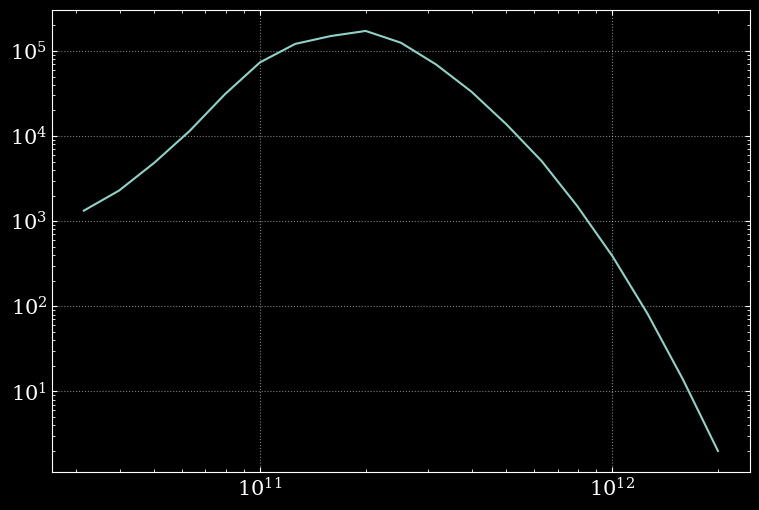

In [ ]:
mbins = 10**np.arange(10.5, 12.4+0.1, 0.1)
N_m = np.histogram(np.concatenate([mdist['mass_1'],mdist['mass_2'],mdist['mass_3'],mdist['mass_4']]), bins=mbins)[0]
plt.loglog(mbins[:-1], N_m)


In [54]:
np.max(np.log10(mdist['mass_4']))

12.400149347166398

In [37]:
np.histogram(np.concatenate([zdist[f'z_{i}'] for i in range(1, 5)]), bins=zbins)[0]

array([ 7369,  7432,  7271,  7854,  8551,  8755,  8901,  8911,  9138,
        9437,  9982,  9991, 10553, 10941, 11052, 11616, 12071, 11817,
       11968, 12341, 13020, 13545, 13368, 13424, 13554, 13768, 13939,
       13782, 14059, 14470, 14290, 14392, 14365, 14773, 15807, 16286,
       16713, 17147, 17868, 18971, 18626, 18018, 17532, 17525, 17232,
       17361, 16427, 15985, 15984, 15225, 14907, 13488, 13037, 12608,
       11755, 11298, 10245,  9208,  8357,  7805,  7100,  6902,  6048,
        5412,  5142,  4673,  4078,  3726,  3319,  3065])

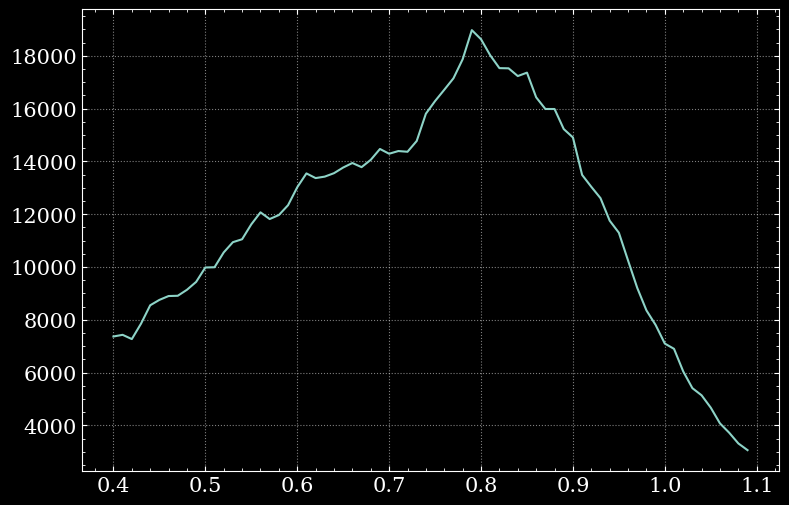

In [26]:
zbins = np.arange(0.4, 1.1+0.01, 0.01)
N_z = np.histogram(np.concatenate([zdist['z_1'],zdist['z_2'],zdist['z_3'],zdist['z_4']]), bins=zbins)[0]
plt.plot(zbins[:-1], N_z)


# Hadzhiyska 2025

# Emily Stefania mdist

In [ ]:
mfile = "/global/homes/c/cpopik/Capybara/Data/mass_distrib.txt"
logmraws = np.log10(np.genfromtxt(mfile))
mbins = np.arange((np.floor(logmraws.min()*10)/10).round(1), (np.ceil(logmraws.max()*10)/10+0.1).round(1), 0.1)
SMF, mstars = np.histogram(logmraws, bins=mbins)
SMF = SMF[None, :]
zs = np.array([0.55])

In [ ]:
# class Zhou2022:  # DESI LRGs (arxiv.org/abs/2208.08515)
#     path = "/global/cfs/projectdirs/desi/public/ets/vac/stellar_mass/v1/"


# class Amodeo2021():
#     mfile = "/global/homes/c/cpopik/Capybara/Data/mass_distrib.txt"
#     def __init__(self):
#         self.logmraws = np.log10(np.genfromtxt(self.mfile))
#         mbins = np.arange((np.floor(self.logmraws.min()*10)/10).round(1), (np.ceil(self.logmraws.max()*10)/10+0.1).round(1), 0.1)
#         self.SMF, self.mstars = np.histogram(self.logmraws, bins=mbins)
#         self.SMF = self.SMF[None, :]
#         self.zs = np.array([0.55])


# class Amodeo2021():
#     # These are how the centers are determind in mop-c-gt and SOLikeT_szlike, then uses Kravstov2014 Mvir_scatter
#     logmstarbins = np.linspace(9.42, 11.73, 10)
#     logmstar = (logmstarbins[1:]+logmstarbins[:-1])/2
    
#     def __init__(self):
#         pass

In [ ]:
ViewDataOrganization("/global/cfs/projectdirs/desi/public/dr1/target/", info=False, levels=1)

In [ ]:
import h5py

with h5py.File("/global/homes/c/cpopik/Stacking_Correlating/ACTDR6DESILRG_Spectra_NEW.h5", "r") as f:
    # List all groups at the root level
    print("Keys:", list(f.keys()))
    print("Keys:", list(f['TxI'].keys()))
    print("Keys:", list(f['TxI/cib_cibdBeta'].keys()))
    print("Keys:", list(f['TxI/cib_cibdBeta/1'].keys()))
    print("Keys:", f['TxI/cib_cibdBeta/1/1.2_10.7'][()])
    plt.loglog(f['ell'][()], f['TxI/cib_cibdBeta/1/1.2_10.7'][()])

In [ ]:
datapath = "/global/homes/c/cpopik/Data/"
zbin, dBeta = '1', '1.4'

fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

dBetastr = f"dBeta_{dBeta}_10.7" if dBeta!='fiducial' else 'fiducial'
tSZdatafile = f"{datapath}/Liu2025_shared/DESI_pz{zbin}_act_dr6_{dBetastr}/diskring_tsz_uniformweight_measured.txt"
thetas = np.genfromtxt(tSZdatafile).T[0]  # [arcmin]
tSZdata, tSZerr = np.genfromtxt(tSZdatafile).T[1:3]*u.sr.to(u.arcmin**2)  # [ster]->[arcmin^2]

colstr = f"pz{zbin}_act_dr6_{dBetastr[1:-5] if dBeta!='fiducial' else 'fiducial'}"
axs[0].errorbar(CIBdBetadp['RApArcmin'], CIBdBetadp[colstr], yerr=CIBdBetadp[colstr+'_err'], capsize=5, label='CIBdBetadp')
axs[0].errorbar(CIBdp_TCIB24['RApArcmin'], CIBdp_TCIB24[colstr], yerr=CIBdp_TCIB24[colstr+'_err'], capsize=5, label='CIBdp_TCIB24')
axs[0].errorbar(CIBdBetadp_TCIB24['RApArcmin'], CIBdBetadp_TCIB24[colstr], yerr=CIBdBetadp_TCIB24[colstr+'_err'], capsize=5, label='CIBdBetadp_TCIB24')

axs[0].errorbar(thetas, tSZdata, yerr=tSZerr, capsize=5, ls='--', label='shared')

tSZcovfile = f"{datapath}/Liu2025_shared/DESI_pz{zbin}_act_dr6_{dBetastr}/cov_diskring_tsz_uniformweight_bootstrap.txt"
tSZcov = np.genfromtxt(tSZcovfile).T*u.sr.to(u.arcmin**2)**2  # [ster]->[arcmin^2]
axs[1].plot(CIBdBetadp['RApArcmin'], CIBdBetadp[colstr+'_err'], label='CIBdBetadp')
axs[1].plot(CIBdp_TCIB24['RApArcmin'], CIBdp_TCIB24[colstr+'_err'], label='CIBdp_TCIB24')
axs[1].plot(CIBdBetadp_TCIB24['RApArcmin'], CIBdBetadp_TCIB24[colstr+'_err'], label='CIBdBetadp_TCIB24')
axs[1].plot(thetas, np.diag(tSZcov)**0.5, ls='--', label='shared')

axs[0].legend(title=f"zbin{zbin}, dBeta{dBeta}"), axs[1].legend(title=f"zbin{zbin}, dBeta{dBeta}")

plt.show()